# **Lab 4: Regression and Classification Evaluation Metrics**

## Part 1: Comprehensive Study of K-Nearest Neighbours (KNN) Classification using Breast Cancer Dataset and Comparison with Regression Evaluation Metrics

Aim: 

To implement KNN classification on the Breast Cancer dataset and analyze model performance using train-test split, heuristic K selection, cross-validation, ROC-AUC, and classification metrics. Also, to compare classification metrics with regression metrics studied in Linear Regression (Lab 3).


Problem Statement: 

A healthcare analytics team is developing a predictive model for early cancer detection. You are required to build a KNN classifier, optimize its performance using different validation techniques, and compare classification evaluation metrics with regression evaluation metrics from Lab 3.


### **Task 1: Data Preparation**


* Load the dataset using sklearn.
* Convert into DataFrame and explore structure.
* Check missing values and duplicates.
* Apply feature scaling using StandardScaler and justify its importance.


In [2]:
import pandas as pd
df= pd.read_csv('brca.csv')
df.head()

,Unnamed: 0,x.radius_mean,x.texture_mean,x.perimeter_mean,x.area_mean,x.smoothness_mean,x.compactness_mean,x.concavity_mean,x.concave_pts_mean,x.symmetry_mean,...,x.texture_worst,x.perimeter_worst,x.area_worst,x.smoothness_worst,x.compactness_worst,x.concavity_worst,x.concave_pts_worst,x.symmetry_worst,x.fractal_dim_worst,y
0,1,13.540,14.36,87.46,566.3,0.09779,0.08129,0.06664,0.047810,0.1885,...,19.26,99.70,711.2,0.14400,0.17730,0.23900,0.12880,0.2977,0.07259,B
1,2,13.080,15.71,85.63,520.0,0.10750,0.12700,0.04568,0.031100,0.1967,...,20.49,96.09,630.5,0.13120,0.27760,0.18900,0.07283,0.3184,0.08183,B
2,3,9.504,12.44,60.34,273.9,0.10240,0.06492,0.02956,0.020760,0.1815,...,15.66,65.13,314.9,0.13240,0.11480,0.08867,0.06227,0.2450,0.07773,B
3,4,13.030,18.42,82.61,523.8,0.08983,0.03766,0.02562,0.029230,0.1467,...,22.81,84.46,545.9,0.09701,0.04619,0.04833,0.05013,0.1987,0.06169,B
4,5,8.196,16.84,51.71,201.9,0.08600,0.05943,0.01588,0.005917,0.1769,...,21.96,57.26,242.2,0.12970,0.13570,0.06880,0.02564,0.3105,0.07409,B


In [3]:
df.shape

(569, 32)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Unnamed: 0           569 non-null    int64  
 1   x.radius_mean        569 non-null    float64
 2   x.texture_mean       569 non-null    float64
 3   x.perimeter_mean     569 non-null    float64
 4   x.area_mean          569 non-null    float64
 5   x.smoothness_mean    569 non-null    float64
 6   x.compactness_mean   569 non-null    float64
 7   x.concavity_mean     569 non-null    float64
 8   x.concave_pts_mean   569 non-null    float64
 9   x.symmetry_mean      569 non-null    float64
 10  x.fractal_dim_mean   569 non-null    float64
 11  x.radius_se          569 non-null    float64
 12  x.texture_se         569 non-null    float64
 13  x.perimeter_se       569 non-null    float64
 14  x.area_se            569 non-null    float64
 15  x.smoothness_se      569 non-null    flo

In [5]:
df.describe()

,Unnamed: 0,x.radius_mean,x.texture_mean,x.perimeter_mean,x.area_mean,x.smoothness_mean,x.compactness_mean,x.concavity_mean,x.concave_pts_mean,x.symmetry_mean,...,x.radius_worst,x.texture_worst,x.perimeter_worst,x.area_worst,x.smoothness_worst,x.compactness_worst,x.concavity_worst,x.concave_pts_worst,x.symmetry_worst,x.fractal_dim_worst
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,285.000000,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,164.400426,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,1.000000,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,143.000000,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,285.000000,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,427.000000,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,569.000000,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [6]:
df['y'].value_counts()

y
B    357
M    212
Name: count, dtype: int64

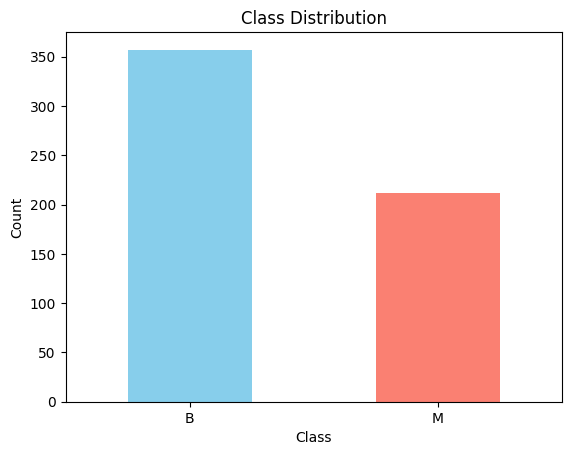

In [7]:
import matplotlib.pyplot as plt

# Bar plot of class counts
df['y'].value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

B= Benign

M = Malignant

In [8]:
df.isna().sum()

Unnamed: 0             0
x.radius_mean          0
x.texture_mean         0
x.perimeter_mean       0
x.area_mean            0
x.smoothness_mean      0
x.compactness_mean     0
x.concavity_mean       0
x.concave_pts_mean     0
x.symmetry_mean        0
x.fractal_dim_mean     0
x.radius_se            0
x.texture_se           0
x.perimeter_se         0
x.area_se              0
x.smoothness_se        0
x.compactness_se       0
x.concavity_se         0
x.concave_pts_se       0
x.symmetry_se          0
x.fractal_dim_se       0
x.radius_worst         0
x.texture_worst        0
x.perimeter_worst      0
x.area_worst           0
x.smoothness_worst     0
x.compactness_worst    0
x.concavity_worst      0
x.concave_pts_worst    0
x.symmetry_worst       0
x.fractal_dim_worst    0
y                      0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

No missing values and no duplicates

df.describe() shows variance in the minimum and maximum values among all the numeric columns and the range is vast. Therefore, feature scaling is required to reduce the variance in scales across variables, ensuring that all features contribute proportionally to the model's objective function.

In [10]:
import numpy as np

numeric_cols = df.select_dtypes(include=[np.number]).columns

results = []

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col]
    
    results.append({
        'column': col,
        'mean': df[col].mean(),
        'median': df[col].median(),
        'std': df[col].std(),
        'skewness': df[col].skew(),
        'min': df[col].min(),
        'max': df[col].max(),
        'outlier_count': outliers.shape[0],
        'outlier_pct': round(outliers.shape[0] / df.shape[0] * 100, 2)
    })

summary = pd.DataFrame(results).sort_values('outlier_pct', ascending=False)
pd.set_option('display.max_columns', None)   # Show all columns
pd.set_option('display.width', None)         # Don't wrap based on terminal width
pd.set_option('display.max_colwidth', None)  # Optional

print(summary)

                 column        mean      median         std  skewness  \
14            x.area_se   40.337079   24.530000   45.491006  5.447186   
11          x.radius_se    0.405172    0.324200    0.277313  3.088612   
13       x.perimeter_se    2.866059    2.287000    2.021855  3.443615   
24         x.area_worst  880.583128  686.500000  569.356993  1.859373   
15      x.smoothness_se    0.007041    0.006380    0.003003  2.314450   
16     x.compactness_se    0.025478    0.020450    0.017908  1.902221   
20     x.fractal_dim_se    0.003795    0.003187    0.002646  3.923969   
19        x.symmetry_se    0.020542    0.018730    0.008266  2.195133   
4           x.area_mean  654.889104  551.100000  351.914129  1.645732   
30  x.fractal_dim_worst    0.083946    0.080040    0.018061  1.662579   
29     x.symmetry_worst    0.290076    0.282200    0.061867  1.433928   
17       x.concavity_se    0.031894    0.025890    0.030186  5.110463   
12         x.texture_se    1.216853    1.108000    

Feature scaling is applied using StandardScaler(Z-score normalisation) to standardize all numeric features to zero mean and unit variance, as required for distance-based and gradient-based models. Exploratory analysis of skewness and outlier percentages (via the IQR method) across all 32 numeric columns showed that the majority of features exhibit low-to-moderate skewness (<1.6) and outlier rates below 5%, supporting StandardScaler's mean/variance-based approach. A subset of standard-error features showed higher skewness (up to 5.45) and outlier percentages (up to 11.4%), which would typically favor a median/IQR-based scaler such as RobustScaler; however, StandardScaler was applied uniformly across all features per assignment requirements.

In [11]:
df.columns

Index(['Unnamed: 0', 'x.radius_mean', 'x.texture_mean', 'x.perimeter_mean',
       'x.area_mean', 'x.smoothness_mean', 'x.compactness_mean',
       'x.concavity_mean', 'x.concave_pts_mean', 'x.symmetry_mean',
       'x.fractal_dim_mean', 'x.radius_se', 'x.texture_se', 'x.perimeter_se',
       'x.area_se', 'x.smoothness_se', 'x.compactness_se', 'x.concavity_se',
       'x.concave_pts_se', 'x.symmetry_se', 'x.fractal_dim_se',
       'x.radius_worst', 'x.texture_worst', 'x.perimeter_worst',
       'x.area_worst', 'x.smoothness_worst', 'x.compactness_worst',
       'x.concavity_worst', 'x.concave_pts_worst', 'x.symmetry_worst',
       'x.fractal_dim_worst', 'y'],
      dtype='object')

In [12]:
df.drop('Unnamed: 0',axis=1,inplace=True)

In [13]:
df.head()

,x.radius_mean,x.texture_mean,x.perimeter_mean,x.area_mean,x.smoothness_mean,x.compactness_mean,x.concavity_mean,x.concave_pts_mean,x.symmetry_mean,x.fractal_dim_mean,x.radius_se,x.texture_se,x.perimeter_se,x.area_se,x.smoothness_se,x.compactness_se,x.concavity_se,x.concave_pts_se,x.symmetry_se,x.fractal_dim_se,x.radius_worst,x.texture_worst,x.perimeter_worst,x.area_worst,x.smoothness_worst,x.compactness_worst,x.concavity_worst,x.concave_pts_worst,x.symmetry_worst,x.fractal_dim_worst,y
0,13.540,14.36,87.46,566.3,0.09779,0.08129,0.06664,0.047810,0.1885,0.05766,0.2699,0.7886,2.058,23.560,0.008462,0.014600,0.02387,0.013150,0.01980,0.002300,15.110,19.26,99.70,711.2,0.14400,0.17730,0.23900,0.12880,0.2977,0.07259,B
1,13.080,15.71,85.63,520.0,0.10750,0.12700,0.04568,0.031100,0.1967,0.06811,0.1852,0.7477,1.383,14.670,0.004097,0.018980,0.01698,0.006490,0.01678,0.002425,14.500,20.49,96.09,630.5,0.13120,0.27760,0.18900,0.07283,0.3184,0.08183,B
2,9.504,12.44,60.34,273.9,0.10240,0.06492,0.02956,0.020760,0.1815,0.06905,0.2773,0.9768,1.909,15.700,0.009606,0.014320,0.01985,0.014210,0.02027,0.002968,10.230,15.66,65.13,314.9,0.13240,0.11480,0.08867,0.06227,0.2450,0.07773,B
3,13.030,18.42,82.61,523.8,0.08983,0.03766,0.02562,0.029230,0.1467,0.05863,0.1839,2.3420,1.170,14.160,0.004352,0.004899,0.01343,0.011640,0.02671,0.001777,13.300,22.81,84.46,545.9,0.09701,0.04619,0.04833,0.05013,0.1987,0.06169,B
4,8.196,16.84,51.71,201.9,0.08600,0.05943,0.01588,0.005917,0.1769,0.06503,0.1563,0.9567,1.094,8.205,0.008968,0.016460,0.01588,0.005917,0.02574,0.002582,8.964,21.96,57.26,242.2,0.12970,0.13570,0.06880,0.02564,0.3105,0.07409,B


### **Task 2: Train-Test Split Analysis**


* Split dataset into training and testing sets (80:20).
* Repeat with 70:30 and 90:10 splits.
* Compare performance variations across splits.
* Analyze how dataset splitting affects model stability and generalization.


In [14]:
#General Function 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

def evaluate_split(X,y,test_size,k):
    X_train, X_test,y_train,y_test = train_test_split(X,y,test_size=test_size,random_state=42,stratify=y) # straitfy to ensure that the ratio of class / categories remains the same in both train and test
    scaler=StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_scaled,y_train)

    y_pred=model.predict(X_test_scaled)
    acc= accuracy_score(y_test,y_pred)

    return acc, X_train.shape[0], X_test.shape[0]

In [15]:
split_ratio={
    '80:20' : 0.2,
    '70:30' : 0.3,
    '90:10' : 0.1
}
results=[]
X=df.drop('y',axis=1)
y=df['y']
for split_name, test_size in split_ratio.items():
    acc,n_train,n_test = evaluate_split(X,y,test_size,5)
    results.append({
        'Split Ratio' : split_name,
        'Train sample size': n_train,
        'Test sample size': n_test,
        'Accuracy': acc
    })
    print(f"{split_name} => Train: {n_train}, Test: {n_test}, Accuracy: {acc:.4f}")


80:20 => Train: 455, Test: 114, Accuracy: 0.9561
70:30 => Train: 398, Test: 171, Accuracy: 0.9649
90:10 => Train: 512, Test: 57, Accuracy: 0.9649


70:30 & 90:10 split shows the best accuract of 0.9649

In [16]:
split_ratio={
    '80:20' : 0.2,
    '70:30' : 0.3,
    '90:10' : 0.1
}
results=[]
X=df.drop('y',axis=1)
y=df['y']
for split_name, test_size in split_ratio.items():
    acc,n_train,n_test = evaluate_split(X,y,test_size,21)
    results.append({
        'Split Ratio' : split_name,
        'Train sample size': n_train,
        'Test sample size': n_test,
        'Accuracy': acc
    })
    print(f"{split_name} => Train: {n_train}, Test: {n_test}, Accuracy: {acc:.4f}")


80:20 => Train: 455, Test: 114, Accuracy: 0.9386
70:30 => Train: 398, Test: 171, Accuracy: 0.9532
90:10 => Train: 512, Test: 57, Accuracy: 0.9474


70:30 split shows best accuracy when k=21 (heuristic k value)

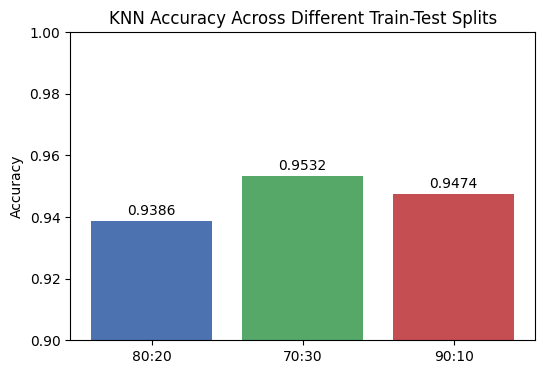

In [17]:
import matplotlib.pyplot as plt

results_df = pd.DataFrame(results) 

plt.figure(figsize=(6,4))
plt.bar(results_df['Split Ratio'], results_df['Accuracy'], color=['#4C72B0', '#55A868', '#C44E52'])
plt.ylim(0.90, 1.0) 
plt.ylabel('Accuracy')
plt.title('KNN Accuracy Across Different Train-Test Splits')

for i, v in enumerate(results_df['Accuracy']):
    plt.text(i, v + 0.002, f"{v:.4f}", ha='center')

plt.show()

Across the three split ratios, KNN accuracy remained fairly stable, ranging from 95.61% (80:20) to 96.49% (70:30 and 90:10), a spread of less than 1 percentage point. This indicates the model generalizes reasonably well and is not highly sensitive to the proportion of training data used. This suggests that beyond a certain point, adding more training data (as in 90:10) does not necessarily improve test performance, and the specific samples included in the test set can matter more than the split ratio itself.

### **Task 3: KNN Model with Heuristic K Selection**

3.1 Heuristic Method for K Selection

* Compute initial K using heuristic rule (K =√n);where n = number of training samples 
* Use this value as a baseline K.


In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [19]:
import numpy as np

n = X_train.shape[0] 
k_heuristic = int(np.sqrt(n))

if k_heuristic % 2 == 0:
    k_heuristic += 1

print(f"Number of training samples: {n}")
print(f"Heuristic K (√n): {k_heuristic}")

Number of training samples: 455
Heuristic K (√n): 21


3.2 Model Training

* Train KNN classifier using heuristic K value.
* Experiment with nearby values of K (K ± 5).
* Plot accuracy vs K values.
* Identify optimal K based on performance trend.


In [20]:
k_range = range(k_heuristic - 5, k_heuristic + 6)
accuracies = []

for k in k_range:
    if k <= 0: 
        continue
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append({'K': k, 'Accuracy': acc})
    print(f"K={k} → Accuracy: {acc:.4f}")

K=16 → Accuracy: 0.9386
K=17 → Accuracy: 0.9386
K=18 → Accuracy: 0.9386
K=19 → Accuracy: 0.9386
K=20 → Accuracy: 0.9386
K=21 → Accuracy: 0.9386
K=22 → Accuracy: 0.9386
K=23 → Accuracy: 0.9386
K=24 → Accuracy: 0.9474
K=25 → Accuracy: 0.9474
K=26 → Accuracy: 0.9474


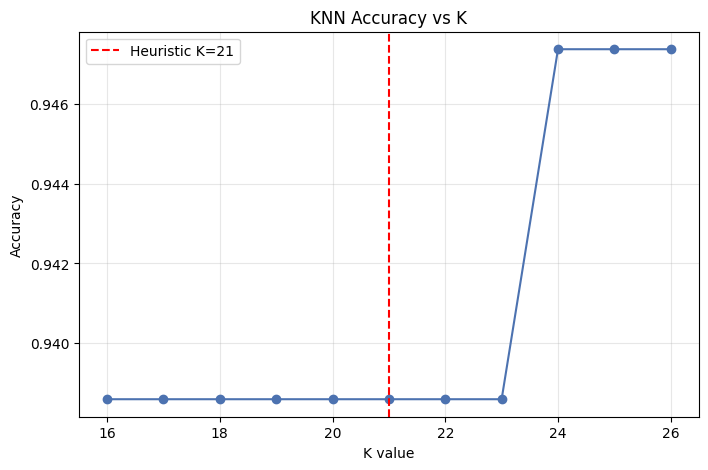

In [21]:
import matplotlib.pyplot as plt

acc_df = pd.DataFrame(accuracies)

plt.figure(figsize=(8,5))
plt.plot(acc_df['K'], acc_df['Accuracy'], marker='o', color='#4C72B0')
plt.axvline(x=k_heuristic, color='red', linestyle='--', label=f'Heuristic K={k_heuristic}')
plt.xlabel('K value')
plt.ylabel('Accuracy')
plt.title('KNN Accuracy vs K')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [22]:
best_row = acc_df.loc[acc_df['Accuracy'].idxmax()]
print(f"Best K in this range: {int(best_row['K'])}, Accuracy: {best_row['Accuracy']:.4f}")

Best K in this range: 24, Accuracy: 0.9474


Since the k value must be odd, 24 + 1 = 25 will be the best K

3.3 Distance Matrix and Decision Boundary Mapping 

* Explain any two distance metrics used in KNN: Euclidean Distance and Manhattan Distance. Also mention when each distance metric is suitable.
* Plot the decision boundary of the KNN classifier for different values of K, such as K = 1, K = 5, K = 10, and K = 20. Analyze how the decision boundary changes as K increase


**Distance Metrics in KNN**

KNN relies on distance metrics to identify the "nearest" neighbors to a given data point. Two commonly used metrics are Euclidean Distance and Manhattan Distance.


**Euclidean Distance**

Euclidean distance measures the straight-line distance between two points in feature space.

$$d(p,q) = \sqrt{\sum_{i=1}^{n}(p_i - q_i)^2}$$

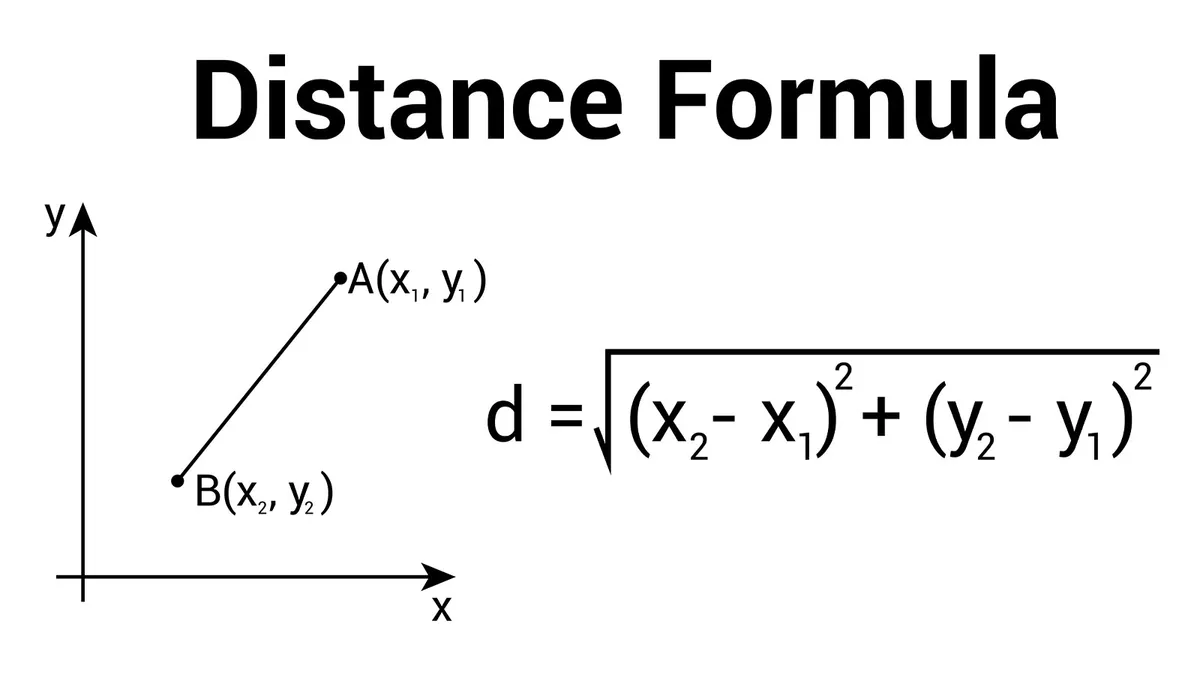

Euclidean distance works best when features are continuous and on comparable scales (hence the importance of feature scaling prior to applying KNN). It is the default and most widely used metric, and is well suited to datasets like the Breast Cancer Wisconsin dataset, where features represent continuous physical measurements (radius, perimeter, area, etc.) and the geometric distance between points is meaningful.

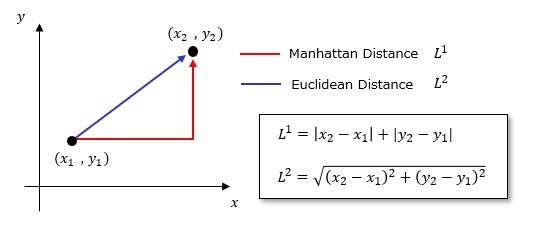


**Manhattan Distance**

Manhattan distance measures distance by summing the absolute differences along each dimension, similar to navigating a grid of city blocks where only horizontal and vertical movement is allowed (no diagonals).

$$d(p,q) = \sum_{i=1}^{n}|p_i - q_i|$$

Manhattan distance is more robust to outliers than Euclidean distance, since it does not square the differences (which would otherwise amplify the effect of large deviations in a single feature). It tends to perform better in high-dimensional spaces and in datasets containing outliers or sparse data.


Euclidean distance is preferred when features are continuous, scaled, and outliers are minimal, while Manhattan distance is more appropriate when the dataset contains outliers or high-dimensional sparse features. Given that the Breast Cancer dataset consists of scaled, continuous numerical features, Euclidean distance is the more natural choice for this KNN implementation, although Manhattan distance could serve as a useful robustness check given the outliers identified in several _se columns during initial data exploration.

In [23]:
y_encoded = y.map({'B': 0, 'M': 1})  # Benign=0, Malignant=1

In [24]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y)

print(dict(zip(le.classes_, le.transform(le.classes_))))

{'B': np.int64(0), 'M': np.int64(1)}


In [25]:
df_corr = X.copy()
df_corr['target'] = y_encoded

correlations = df_corr.corr()['target'].drop('target').sort_values(ascending=False)
print(correlations)

top_2_features = correlations.abs().sort_values(ascending=False).index[:2]
print(f"Top 2 features most correlated with target: {list(top_2_features)}")

x.concave_pts_worst    0.793566
x.perimeter_worst      0.782914
x.concave_pts_mean     0.776614
x.radius_worst         0.776454
x.perimeter_mean       0.742636
x.area_worst           0.733825
x.radius_mean          0.730029
x.area_mean            0.708984
x.concavity_mean       0.696360
x.concavity_worst      0.659610
x.compactness_mean     0.596534
x.compactness_worst    0.590998
x.radius_se            0.567134
x.perimeter_se         0.556141
x.area_se              0.548236
x.texture_worst        0.456903
x.smoothness_worst     0.421465
x.symmetry_worst       0.416294
x.texture_mean         0.415185
x.concave_pts_se       0.408042
x.smoothness_mean      0.358560
x.symmetry_mean        0.330499
x.fractal_dim_worst    0.323872
x.compactness_se       0.292999
x.concavity_se         0.253730
x.fractal_dim_se       0.077972
x.symmetry_se         -0.006522
x.texture_se          -0.008303
x.fractal_dim_mean    -0.012838
x.smoothness_se       -0.067016
Name: target, dtype: float64
Top 2 featu

In [26]:
top_2_features = ['x.concave_pts_worst', 'x.perimeter_worst']

X_2d = X[top_2_features]

X_train_2d, X_test_2d, y_train_2d, y_test_2d = train_test_split(
    X_2d, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

scaler_2d = StandardScaler()
X_train_2d_scaled = scaler_2d.fit_transform(X_train_2d)
X_test_2d_scaled = scaler_2d.transform(X_test_2d)

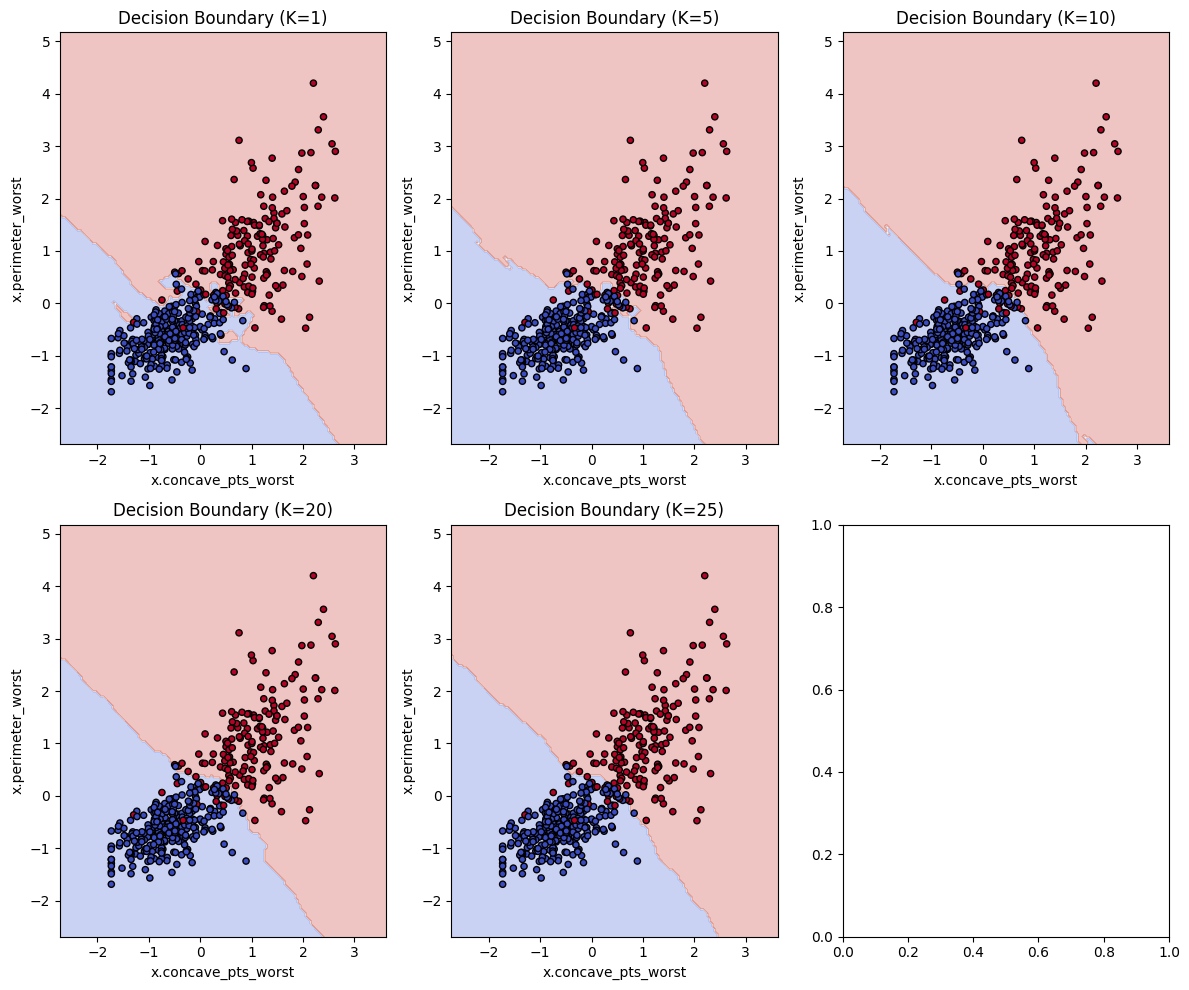

In [27]:
k_values = [1, 5, 10, 20, 25]

fig, axes = plt.subplots(2, 3, figsize=(12, 10))
axes = axes.ravel()

x_min, x_max = X_train_2d_scaled[:, 0].min() - 1, X_train_2d_scaled[:, 0].max() + 1
y_min, y_max = X_train_2d_scaled[:, 1].min() - 1, X_train_2d_scaled[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05), np.arange(y_min, y_max, 0.05))

for idx, k in enumerate(k_values):
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_2d_scaled, y_train_2d)
    
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    ax = axes[idx]
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    ax.scatter(X_train_2d_scaled[:, 0], X_train_2d_scaled[:, 1], 
               c=y_train_2d, cmap='coolwarm', edgecolor='k', s=20)
    ax.set_title(f'Decision Boundary (K={k})')
    ax.set_xlabel(top_2_features[0])
    ax.set_ylabel(top_2_features[1])

plt.tight_layout()
plt.show()

**Interpretation: Decision Boundary vs K**

The four plots show the KNN decision boundary for K = 1, 5, 10, and 20, using the two features most correlated with the target: concave_pts_worst and perimeter_worst.

**K = 1:** The boundary is the most irregular of the four, with small jagged pockets and isolated intrusions near the class overlap region (visible as small blue/red "islands" bleeding into the opposite region around the 0–1 range). This reflects high variance, the model is fitting to individual training points rather than the overall class trend, making it more sensitive to noise and outliers.

**K = 5:** The boundary is noticeably smoother than K=1, with fewer small pockets, though minor irregularities remain near the class overlap zone. This represents a better balance between capturing genuine class structure and avoiding overfitting to individual points.

**K = 10:** The boundary continues to smooth out further, forming a nearly clean diagonal separation between the two classes. Small overlaps between benign and malignant points near the boundary remain, but they reflect genuine class overlap in the data rather than model noise.

**K = 20:** The boundary is the smoothest of all four, forming an almost straight diagonal line. While this reduces variance, it also risks slightly higher bias,  the model is now averaging over a larger neighborhood, which could smooth over finer local patterns in the class overlap region.

As K increases from 1 to 20, the decision boundary transitions from a highly flexible, noise-sensitive boundary (overfitting risk at low K) to a smoother, more generalized boundary (underfitting risk at high K). The two classes (benign and malignant) show fairly strong separation overall based on these two features alone, with most misclassification-prone points concentrated in the narrow overlap region between roughly 0 and 1 on both axes, regardless of K.

**Trying PCA Approach**

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(type(X_train_scaled), X_train_scaled.dtype)

<class 'numpy.ndarray'> float64


In [29]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total variance captured:", sum(pca.explained_variance_ratio_))

Explained variance ratio: [0.44593522 0.18545255]
Total variance captured: 0.631387776559559


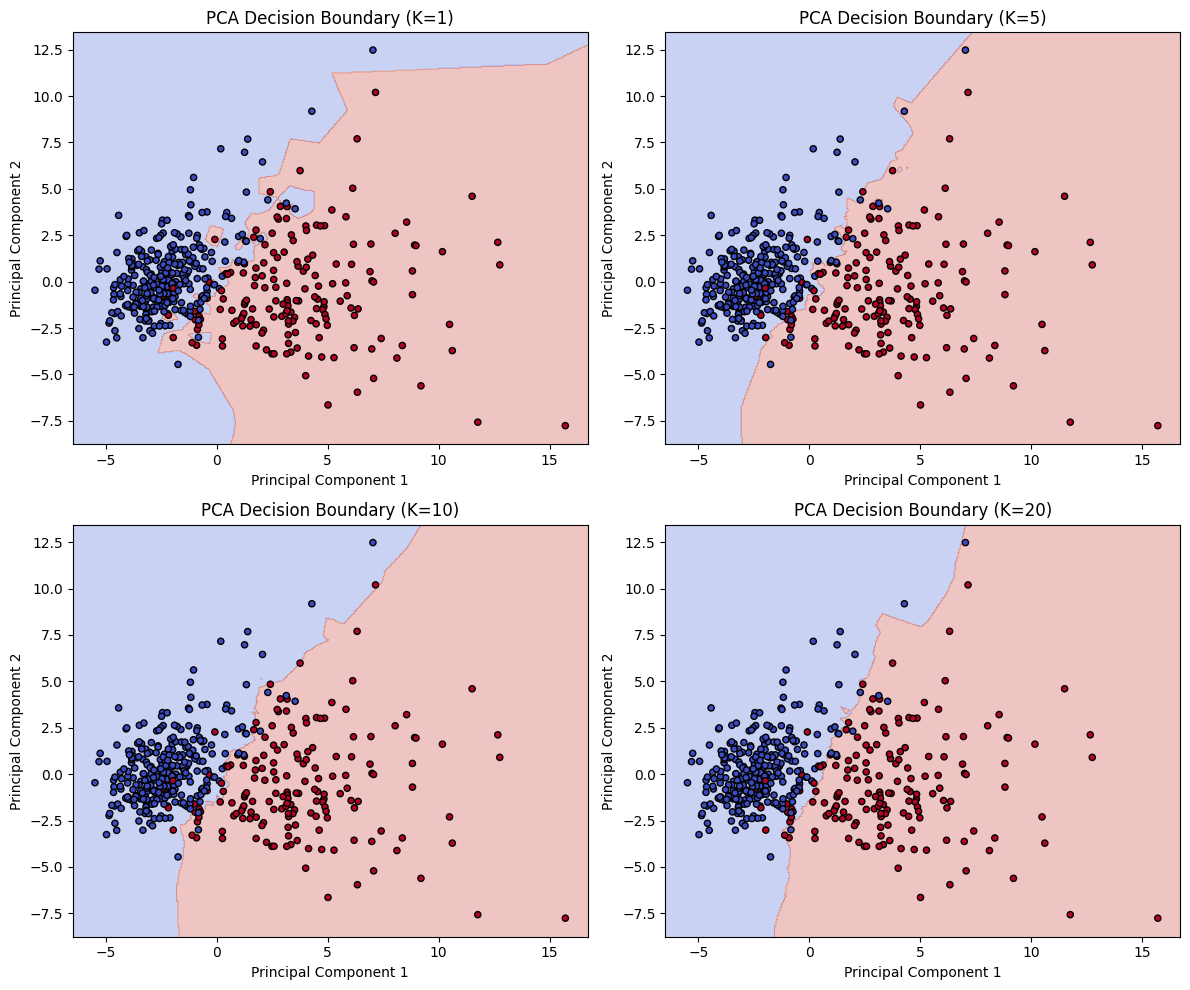

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier

k_values = [1, 5, 10, 20]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

x_min, x_max = X_train_pca[:, 0].min() - 1, X_train_pca[:, 0].max() + 1
y_min, y_max = X_train_pca[:, 1].min() - 1, X_train_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05), np.arange(y_min, y_max, 0.05))

for idx, k in enumerate(k_values):
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_pca, y_train)
    
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    ax = axes[idx]
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    ax.scatter(X_train_pca[:, 0], X_train_pca[:, 1], 
               c=y_train, cmap='coolwarm', edgecolor='k', s=20)
    ax.set_title(f'PCA Decision Boundary (K={k})')
    ax.set_xlabel('Principal Component 1')
    ax.set_ylabel('Principal Component 2')

plt.tight_layout()
plt.show()

**PCA-Based Decision Boundary**

Using PCA to reduce all 30 features to 2 principal components, the decision boundary shows a clear diagonal-curved separation between benign (blue) and malignant (red) classes. A bias-variance trend is still visible across K = 1, 5, 10, and 20, though it is more subtle than in the correlation-based 2-feature version.

At K=1, the boundary shows a small irregular notch intruding into the blue region (around PC1 ≈ 0–2, PC2 ≈ -5 to -6), reflecting the model reacting to individual nearby points. As K increases to 5 and 10, this notch gradually smooths out. By K=20, the boundary is the smoothest of the four, with the irregular notch almost fully flattened into the overall curve.

This trend is less pronounced than in the 2-correlated-feature case because PC1 already captures the dominant axis of variation in the data, producing a fairly clean separation even at low K. The remaining irregularity at low K is concentrated in the region where the two classes overlap most (near the diagonal boundary), which is exactly where individual-point sensitivity would be expected to show up.


Both approaches confirm the expected bias-variance trade-off as K increases, though the effect is more visually dramatic in the correlation-based plots. This makes sense: PCA's PC1 already aligns closely with the direction of maximum class separation, so the model needs fewer neighbors to produce a fairly stable boundary, whereas the correlation-based 2-feature space likely has more local noise for the model to react to at low K.

### **Task 4: Cross Validation**

* Apply K-Fold Cross Validation (k = 5 or 10).
* Compute mean accuracy for different K values.
* Compare cross-validation results with train-test split results.
* Select best K based on both heuristic + validation results.


Cross-validation is a statistical technique used to evaluate how well a machine learning model generalizes to unseen data. It works by partitioning a dataset into subsets, training the model on some subsets while testing it on the remaining ones, and repeating the process iteratively to avoid overfitting.

i.e
Instead of one train-test split, K-Fold CV splits your data into k equal parts ("folds"), trains on k-1 of them, tests on the remaining 1, and repeats this k times so every fold gets used as the test set once. Then it averages the accuracy across all k runs.


In [31]:
from sklearn.model_selection import cross_val_score
import numpy as np

k_range = range(1, 27) 
cv_scores = []

for k in k_range:
    model = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='accuracy') 
    cv_scores.append(scores.mean())
    print(f"K={k} → Mean CV Accuracy: {scores.mean():.4f} (+/- {scores.std():.4f})")

K=1 → Mean CV Accuracy: 0.9473 (+/- 0.0146)
K=2 → Mean CV Accuracy: 0.9560 (+/- 0.0197)
K=3 → Mean CV Accuracy: 0.9692 (+/- 0.0213)
K=4 → Mean CV Accuracy: 0.9604 (+/- 0.0266)
K=5 → Mean CV Accuracy: 0.9626 (+/- 0.0237)
K=6 → Mean CV Accuracy: 0.9582 (+/- 0.0213)
K=7 → Mean CV Accuracy: 0.9692 (+/- 0.0235)
K=8 → Mean CV Accuracy: 0.9626 (+/- 0.0192)
K=9 → Mean CV Accuracy: 0.9648 (+/- 0.0189)
K=10 → Mean CV Accuracy: 0.9604 (+/- 0.0179)
K=11 → Mean CV Accuracy: 0.9582 (+/- 0.0213)
K=12 → Mean CV Accuracy: 0.9582 (+/- 0.0189)
K=13 → Mean CV Accuracy: 0.9582 (+/- 0.0189)
K=14 → Mean CV Accuracy: 0.9560 (+/- 0.0197)
K=15 → Mean CV Accuracy: 0.9604 (+/- 0.0179)
K=16 → Mean CV Accuracy: 0.9582 (+/- 0.0189)
K=17 → Mean CV Accuracy: 0.9604 (+/- 0.0179)
K=18 → Mean CV Accuracy: 0.9560 (+/- 0.0184)
K=19 → Mean CV Accuracy: 0.9560 (+/- 0.0184)
K=20 → Mean CV Accuracy: 0.9560 (+/- 0.0184)
K=21 → Mean CV Accuracy: 0.9560 (+/- 0.0184)
K=22 → Mean CV Accuracy: 0.9538 (+/- 0.0189)
K=23 → Mean CV Accu

In [32]:
k_range = range(1, 27)
accuracies = []

for k in k_range:
    if k <= 0: 
        continue
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append({'K': k, 'Accuracy': acc})
    print(f"K={k} → Accuracy: {acc:.4f}")

K=1 → Accuracy: 0.9298
K=2 → Accuracy: 0.9123
K=3 → Accuracy: 0.9386
K=4 → Accuracy: 0.9386
K=5 → Accuracy: 0.9561
K=6 → Accuracy: 0.9474
K=7 → Accuracy: 0.9561
K=8 → Accuracy: 0.9474
K=9 → Accuracy: 0.9474
K=10 → Accuracy: 0.9474
K=11 → Accuracy: 0.9474
K=12 → Accuracy: 0.9474
K=13 → Accuracy: 0.9474
K=14 → Accuracy: 0.9386
K=15 → Accuracy: 0.9474
K=16 → Accuracy: 0.9386
K=17 → Accuracy: 0.9386
K=18 → Accuracy: 0.9386
K=19 → Accuracy: 0.9386
K=20 → Accuracy: 0.9386
K=21 → Accuracy: 0.9386
K=22 → Accuracy: 0.9386
K=23 → Accuracy: 0.9386
K=24 → Accuracy: 0.9474
K=25 → Accuracy: 0.9474
K=26 → Accuracy: 0.9474


In [33]:

train_test_acc = {item['K']: item['Accuracy'] for item in accuracies}

cv_acc = {i + 1: score for i, score in enumerate(cv_scores)}

print(train_test_acc)
print(cv_acc)

{1: 0.9298245614035088, 2: 0.9122807017543859, 3: 0.9385964912280702, 4: 0.9385964912280702, 5: 0.956140350877193, 6: 0.9473684210526315, 7: 0.956140350877193, 8: 0.9473684210526315, 9: 0.9473684210526315, 10: 0.9473684210526315, 11: 0.9473684210526315, 12: 0.9473684210526315, 13: 0.9473684210526315, 14: 0.9385964912280702, 15: 0.9473684210526315, 16: 0.9385964912280702, 17: 0.9385964912280702, 18: 0.9385964912280702, 19: 0.9385964912280702, 20: 0.9385964912280702, 21: 0.9385964912280702, 22: 0.9385964912280702, 23: 0.9385964912280702, 24: 0.9473684210526315, 25: 0.9473684210526315, 26: 0.9473684210526315}
{1: np.float64(0.9472527472527472), 2: np.float64(0.956043956043956), 3: np.float64(0.9692307692307693), 4: np.float64(0.9604395604395606), 5: np.float64(0.9626373626373628), 6: np.float64(0.9582417582417582), 7: np.float64(0.9692307692307693), 8: np.float64(0.9626373626373628), 9: np.float64(0.964835164835165), 10: np.float64(0.9604395604395606), 11: np.float64(0.9582417582417584), 

In [34]:
common_k = sorted(set(train_test_acc.keys()) & set(cv_acc.keys()))

comparison_df = pd.DataFrame({
    'K': common_k,
    'Train-Test Accuracy': [train_test_acc[k] for k in common_k],
    'CV Mean Accuracy': [cv_acc[k] for k in common_k],
})
comparison_df['Difference (CV - TT)'] = comparison_df['CV Mean Accuracy'] - comparison_df['Train-Test Accuracy']

print(comparison_df)

     K  Train-Test Accuracy  CV Mean Accuracy  Difference (CV - TT)
0    1             0.929825          0.947253              0.017428
1    2             0.912281          0.956044              0.043763
2    3             0.938596          0.969231              0.030634
3    4             0.938596          0.960440              0.021843
4    5             0.956140          0.962637              0.006497
5    6             0.947368          0.958242              0.010873
6    7             0.956140          0.969231              0.013090
7    8             0.947368          0.962637              0.015269
8    9             0.947368          0.964835              0.017467
9   10             0.947368          0.960440              0.013071
10  11             0.947368          0.958242              0.010873
11  12             0.947368          0.958242              0.010873
12  13             0.947368          0.958242              0.010873
13  14             0.938596          0.956044   

In [35]:
best_k_traintest = max(train_test_acc, key=train_test_acc.get)
best_k_cv = max(cv_acc, key=cv_acc.get)

print(f"Best K (Train-Test): {best_k_traintest}, Accuracy: {train_test_acc[best_k_traintest]:.4f}")
print(f"Best K (CV): {best_k_cv}, Accuracy: {cv_acc[best_k_cv]:.4f}")

Best K (Train-Test): 5, Accuracy: 0.9561
Best K (CV): 3, Accuracy: 0.9692


Considering both train-test split and cross-validation results together, K=7 was selected as the final K value. It is the only K in the tested range to achieve the joint-highest accuracy under both evaluation methods (0.9561 train-test, 0.9692 CV), indicating consistent performance rather than a result specific to one particular data split. While K=3 achieved an equally high CV accuracy, its much larger gap between CV and train-test accuracy (0.0306 vs. 0.0131 for K=7) suggests greater sensitivity to fold composition, making it a less stable choice. K=7 also satisfies the requirement of being an odd value, avoiding tie votes in this binary classification task, and sits within a broader region of consistently strong performance (K=5–9), further supporting its reliability as the final chosen K.

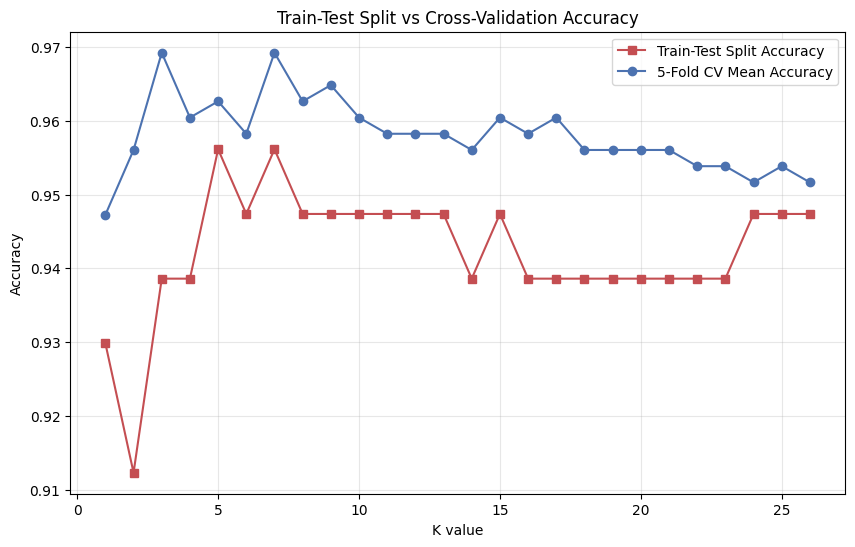

In [36]:
import matplotlib.pyplot as plt

common_k = sorted(set(train_test_acc.keys()) & set(cv_acc.keys()))
tt_vals = [train_test_acc[k] for k in common_k]
cv_vals = [cv_acc[k] for k in common_k]

plt.figure(figsize=(10,6))
plt.plot(common_k, tt_vals, marker='s', label='Train-Test Split Accuracy', color='#C44E52')
plt.plot(common_k, cv_vals, marker='o', label='5-Fold CV Mean Accuracy', color='#4C72B0')
plt.xlabel('K value')
plt.ylabel('Accuracy')
plt.title('Train-Test Split vs Cross-Validation Accuracy')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Cross-validation accuracy stays consistently higher and smoother than train-test split accuracy across almost all K values, showing that a single split underestimates and fluctuates more due to its dependence on one particular sample partition.

### **Task 5: Classification Evaluation**

* Evaluate final model using:
* Accuracy
* Precision
* Recall
* F1 Score
* Confusion Matrix
* ROC Curve and AUC Score


In [37]:
from sklearn.neighbors import KNeighborsClassifier

final_k = 7
final_model = KNeighborsClassifier(n_neighbors=final_k)
final_model.fit(X_train_scaled, y_train)

y_pred = final_model.predict(X_test_scaled)
y_pred_proba = final_model.predict_proba(X_test_scaled)[:, 1]  # probability of class 1, needed for ROC-AUC

**Accuracy, Precision, Recall, F1 Score**

In [38]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall: {rec:.4f}")
print(f"F1 Score: {f1:.4f}")

Accuracy: 0.9561
Precision: 0.9744
Recall: 0.9048
F1 Score: 0.9383


*Accuracy = 0.9561* : Proportion of all predictions that were correct.

The model correctly classified 95.61% of all test cases.


*Precision = 0.9744* : Of all cases predicted as Benign, the proportion that were actually Benign.

When the model predicts "benign," it is correct 97.44% of the time.


*Recall = 0.9048* : Of all actual Benign cases, the proportion correctly identified by the model.

The model correctly caught 90.48% of truly benign cases; the rest were falsely flagged as malignant.


*F1 Score = 0.9383* : Harmonic mean of Precision and Recall, balancing both into one score.

Reflects a strong overall balance between avoiding false benign clearances and avoiding false alarms.


**Confusion Matrix**

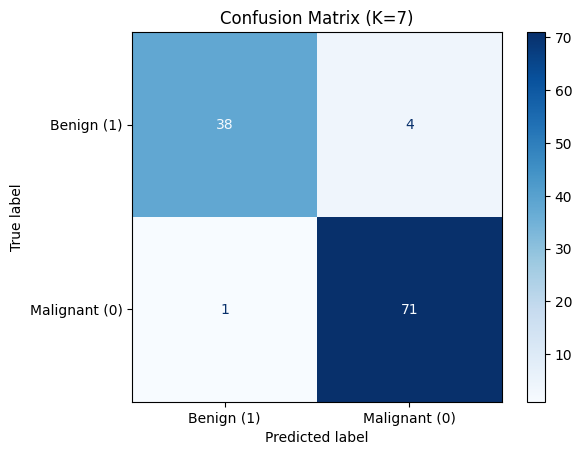

In [39]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred, labels=[1, 0])  # Benign (positive) first, then Malignant

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Benign (1)', 'Malignant (0)'])
disp.plot(cmap='Blues')
plt.title(f'Confusion Matrix (K={final_k})')
plt.show()

Out of 114 test cases, the model correctly classified 71 malignant and 38 benign cases, while misclassifying 1 malignant case as benign (false negative for cancer) and 4 benign cases as malignant (false positive).

**ROC Curve**

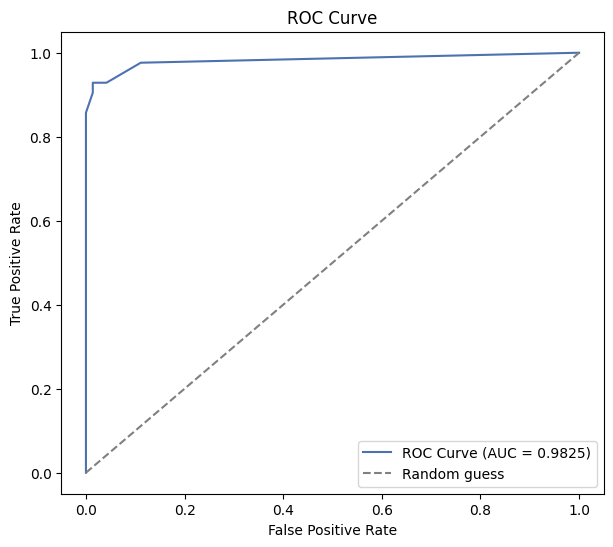

AUC Score: 0.9825


In [40]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
auc_score = roc_auc_score(y_test, y_pred_proba)

plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc_score:.4f})', color='#4C72B0')
plt.plot([0,1], [0,1], linestyle='--', color='gray', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

print(f"AUC Score: {auc_score:.4f}")

The ROC curve rises sharply toward the top-left corner and stays close to it, with an AUC of 0.9825 , indicating the model achieves a high true positive rate while maintaining a very low false positive rate across almost all classification thresholds, reflecting excellent overall class separability.

### **Task 6: Comparative Study with Regression**

Reference: Recall Lab 3 (Linear Regression) where you evaluated:

* MAE

* MSE

* RMSE

* R² Score

Tasks:

* Compare regression evaluation metrics with classification metrics.

* Explain differences between:

* Error-based evaluation (Regression)

* Decision-based evaluation (Classification)


Compare:

* R² Score vs Accuracy

* RMSE vs F1 Score

* MAE vs Confusion Matrix

* Discuss differences in evaluation logic for:

* Continuous prediction tasks

* Classification tasks



Write a detailed inference covering:

* How regression metrics measure prediction error magnitude

* How classification metrics measure decision correctness

* Why is accuracy insufficient in medical diagnosis

* Why recall and ROC-AUC are more relevant in healthcare

* Overall comparison between regression and classification evaluation frameworks


**1. Regression vs Classification Metrics**

Regression metrics (MAE, MSE, RMSE, R²) measure how far off a predicted continuous value is from the actual value. Classification metrics (Accuracy, Precision, Recall, F1) measure whether a predicted category label matches the true category. Regression cares about the size of the error, classification cares about whether the decision was right or wrong.

**2. Error-Based vs Decision-Based Evaluation**

Regression evaluation is error-based. The model predicts a number, and metrics quantify how much that number deviates from the true value, in the same units as the target (or squared units, for MSE).

Classification evaluation is decision-based. The model predicts a discrete label, and metrics quantify whether that label was correct, and if wrong, what kind of mistake it was (false positive vs false negative). There is no concept of "how close" a wrong class prediction was, since Malignant and Benign aren't points on a number line.

**3. Direct Comparisons**

*R² Score vs Accuracy*
R² tells you what proportion of the variance in a continuous target your model explains. Accuracy tells you what proportion of discrete labels your model got right. Both are "overall performance" summaries, but R² is about explained variation, while accuracy is about correct classification count.

*RMSE vs F1 Score*
RMSE penalizes large numeric errors more heavily (since it squares them before averaging), giving a sense of typical prediction error magnitude. F1 balances precision and recall into one number, summarizing how well the model handles both false positives and false negatives together. Neither measures the same thing, but both act as a single "balanced" summary metric within their respective task types.

*MAE vs Confusion Matrix*
MAE gives one average number representing typical absolute error size. A confusion matrix instead breaks down exactly how many predictions fell into each outcome (true positive, false positive, true negative, false negative), giving a more detailed, categorical breakdown rather than a single averaged number.

**4. Continuous vs Classification Evaluation Logic**

For continuous prediction tasks, "closeness" matters. Predicting 210k when the true house price is 200k is a small, tolerable error. Evaluation logic is built around measuring that distance.

For classification tasks, there is no partial credit. Predicting "Malignant" when the truth is "Benign" is simply wrong, regardless of how confident the model was. Evaluation logic instead focuses on counting correct vs incorrect decisions, and further breaking down which type of incorrect decision occurred, since different mistakes carry different real-world costs.

**5 Inference**

Regression metrics like MAE, MSE, and RMSE measure how far predictions deviate from actual values, capturing the magnitude of error in continuous outputs. R² adds a normalized sense of how much variance in the target the model explains overall.

Classification metrics measure decision correctness rather than error magnitude. Accuracy counts overall correct predictions, while precision, recall, and F1 break this down further by looking at specific error types, since not all misclassifications carry equal consequences.

Accuracy alone is insufficient in medical diagnosis because it treats all errors as equal. A model can score high accuracy while still missing several malignant cases, if benign cases dominate the dataset. In cancer detection, missing a malignant case (a false negative) is far more dangerous than a false alarm, so a single "percent correct" number can hide this critical weakness.

Recall and ROC-AUC are more relevant in healthcare because recall directly measures how many actual malignant cases were caught, and ROC-AUC evaluates model performance across all possible decision thresholds rather than just the default cutoff, giving a fuller picture of how well the model separates the two classes regardless of where the threshold is set.

Overall, regression evaluation is about quantifying distance from a continuous truth, while classification evaluation is about quantifying correctness of a categorical decision and the cost of specific types of mistakes. Both frameworks share the same underlying goal of measuring model reliability, but they use fundamentally different logic suited to the nature of their respective prediction tasks.

### **Task 7: Analytical Questions**

**1. Why is KNN called a lazy learning algorithm?**
KNN does not build a model during training. It simply stores the training data and does all the actual computation (distance calculation, neighbor voting) at prediction time. Since there's no upfront learning phase, it's called "lazy."

**2. Why is feature scaling required in KNN?**
KNN relies on distance calculations between points. If features are on different scales (e.g., area in the hundreds vs smoothness in decimals), features with larger numeric ranges dominate the distance calculation, distorting which points are actually "nearest." Scaling puts all features on comparable footing.

**3. Explain heuristic K selection using √n rule.**
A common rule of thumb is to set K equal to the square root of the number of training samples. It's a quick starting estimate that tends to avoid K values that are too small (noisy, overfit) or too large (oversmoothed, underfit), without requiring any tuning.

**4. Why is cross-validation more reliable than a single train-test split?**
A single split gives one accuracy number that depends heavily on which samples happened to land in the test set. Cross-validation repeats the train-test process across multiple folds and averages the results, giving a more stable estimate that isn't overly sensitive to one particular lucky or unlucky split.

**5. How does K affect bias-variance trade-off?**
Small K makes the model flexible and sensitive to individual data points, leading to low bias but high variance (overfitting). Large K smooths predictions by averaging over more neighbors, increasing bias but reducing variance (underfitting). The right K balances the two.

**6. Why is recall more important than accuracy in cancer prediction?**
Accuracy treats a missed cancer case the same as a false alarm. Recall specifically measures how many actual cancer cases were correctly caught, which matters far more clinically, since missing a real malignant case can cost a life, while a false alarm just leads to extra testing.

**7. What is the limitation of very large K values?**
Very large K considers too many neighbors when making a decision, which can smooth over meaningful local patterns in the data and cause the model to underfit, potentially ignoring the actual class boundary in favor of an overly generalized, majority-driven prediction.